# Persona 2 — Indice y Spread

Indice leave-one-out, estimacion de beta, spreads y pruebas de estacionariedad.

## 1. Descarga de datos con cache en CSV

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

tickers = ["GGAL", "BMA", "BBAR", "YPF", "TGS", "EDN", "PAM"]

data_dir = Path('data')
csv_path = data_dir / 'precios_usd.csv'

print('Leyendo CSV de Persona 1...')
data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
print(f'Shape: {data.shape}')
print(f'Rango de fechas: {data.index[0].date()} a {data.index[-1].date()}')
data.head()

Leyendo CSV de Persona 1...
Shape: (4023, 7)
Rango de fechas: 2010-01-04 a 2025-12-30


,BBAR,BMA,EDN,GGAL,PAM,TGS,YPF
Date,,,,,,,
2010-01-04,3.374005,17.192682,8.20,4.194057,11.756643,1.406721,35.911709
2010-01-05,3.642637,17.106396,8.17,4.338931,11.628210,1.467882,35.267986
2010-01-06,3.605027,16.554205,8.39,4.078160,11.065077,1.500816,36.008263
2010-01-07,3.653382,16.646242,8.48,4.223031,11.292306,1.496111,35.662258
2010-01-08,3.690990,16.473677,8.22,4.150597,11.124354,1.491406,36.128960


## 2. Retornos diarios

Calculamos retornos diarios para cada accion:  $r_t = \frac{P_t}{P_{t-1}} - 1$

In [2]:
returns = data.pct_change().dropna()
print(f'Retornos - Shape: {returns.shape}')
print(f'Rango de fechas: {returns.index[0].date()} a {returns.index[-1].date()}')
returns.head()

Retornos - Shape: (4022, 7)
Rango de fechas: 2010-01-05 a 2025-12-30


,BBAR,BMA,EDN,GGAL,PAM,TGS,YPF
Date,,,,,,,
2010-01-05,0.079618,-0.005019,-0.003659,0.034542,-0.010924,0.043478,-0.017925
2010-01-06,-0.010325,-0.032280,0.026928,-0.060100,-0.048428,0.022436,0.020990
2010-01-07,0.013413,0.005560,0.010727,0.035524,0.020536,-0.003135,-0.009609
2010-01-08,0.010294,-0.010367,-0.030660,-0.017152,-0.014873,-0.003145,0.013087
2010-01-11,-0.013100,-0.004190,-0.075426,-0.038394,-0.021314,-0.009464,0.016036


## 3. Indices sinteticos leave-one-out

Para cada accion construimos un indice con el promedio de retornos de **las demas** acciones y lo acumulamos:

$$I_{-a, t} = I_{-a, t-1} \cdot (1 + \bar{r}_{-a, t})$$

con $I_{-a, 0} = 1$

In [3]:
indices_loo = {}

for ticker in tickers:
    otros = [t for t in tickers if t != ticker]
    ret_promedio = returns[otros].mean(axis=1)
    indice = (1 + ret_promedio).cumprod()
    indice.iloc[0] = 1.0
    indices_loo[ticker] = indice

indices_loo = pd.DataFrame(indices_loo, index=returns.index)
print(f'Indices LOO - Shape: {indices_loo.shape}')
indices_loo.head()

Indices LOO - Shape: (4022, 7)


,GGAL,BMA,BBAR,YPF,TGS,EDN,PAM
Date,,,,,,,
2010-01-05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2010-01-06,1.010766,1.012603,0.994927,1.005654,0.995350,1.002307,1.016330
2010-01-07,1.017082,1.023988,1.004811,1.019503,1.007983,1.012712,1.025219
2010-01-08,1.011036,1.016743,0.994242,1.008305,0.999638,1.008973,1.018736
2010-01-11,0.992929,0.992737,0.972244,0.981100,0.976915,0.997130,0.997591


### Verificacion: accion vs su indice leave-one-out

Graficamos cada accion normalizada (base 100) contra su indice LOO.

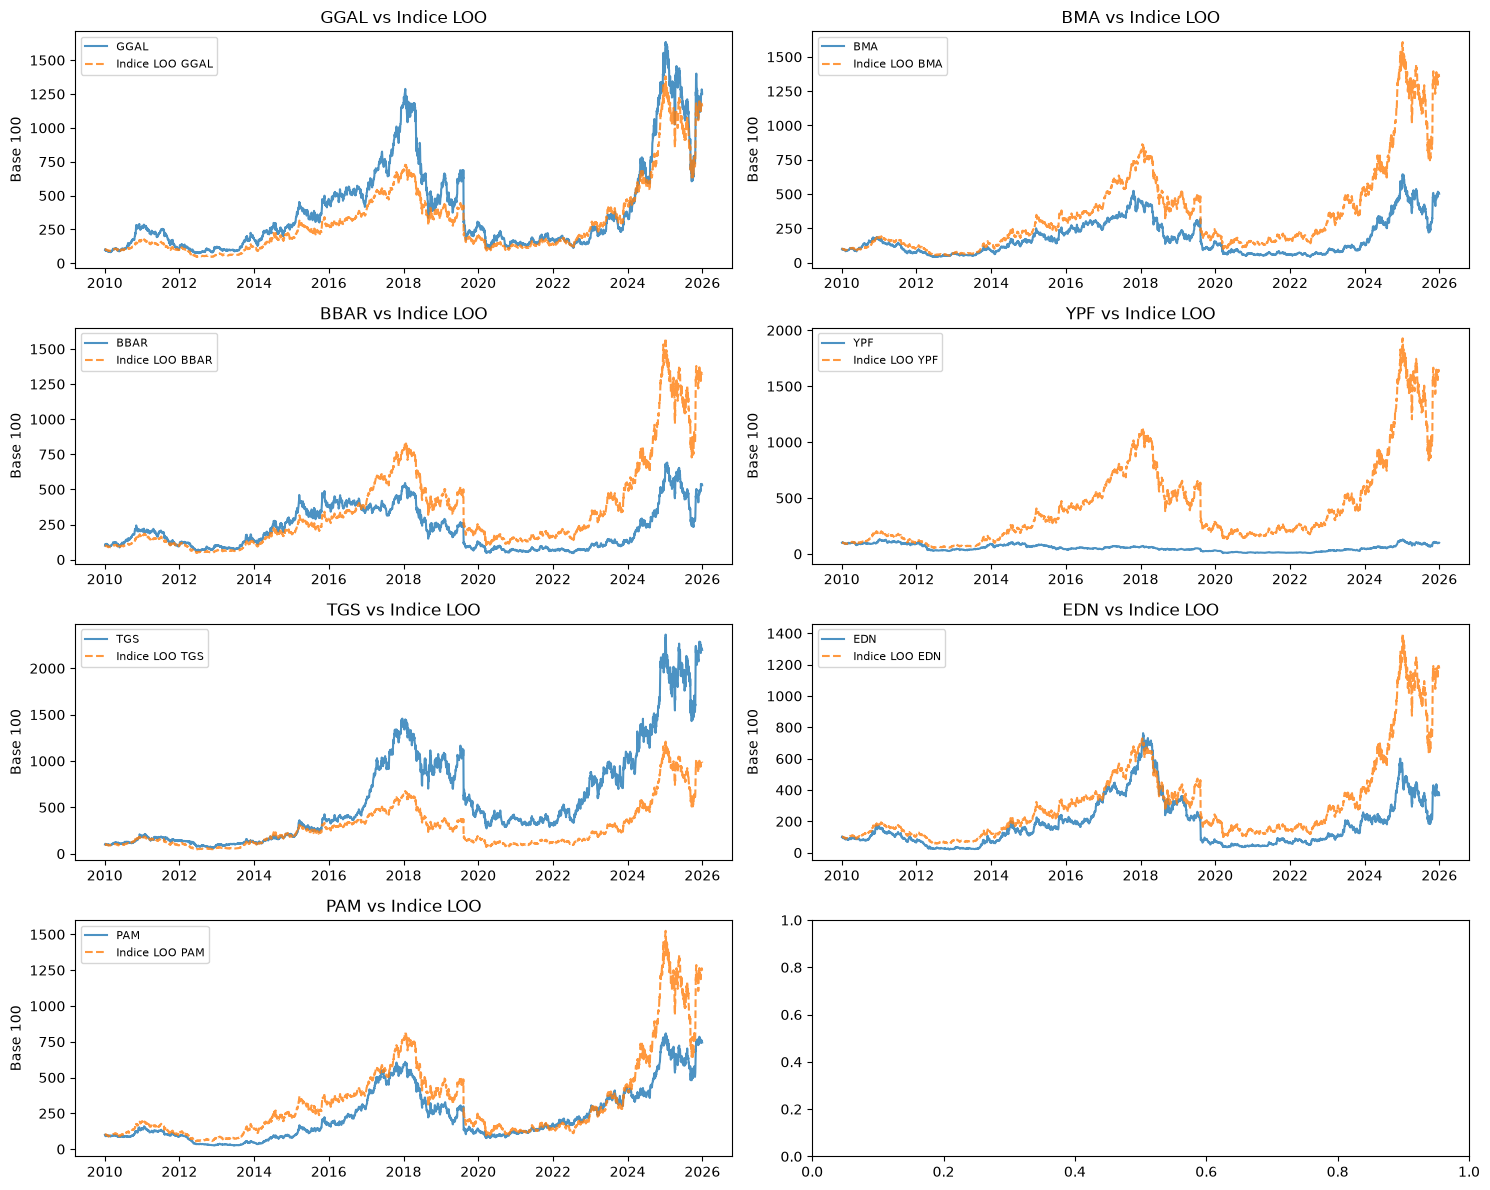

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    precio_norm = data[ticker] / data[ticker].iloc[0] * 100
    indice_norm = indices_loo[ticker] / indices_loo[ticker].iloc[0] * 100
    ax.plot(precio_norm.index, precio_norm, label=ticker, alpha=0.8)
    ax.plot(indice_norm.index, indice_norm, label=f'Indice LOO {ticker}', alpha=0.8, linestyle='--')
    ax.set_title(f'{ticker} vs Indice LOO')
    ax.legend(fontsize=8)
    ax.set_ylabel('Base 100')

plt.tight_layout()
plt.show()

### Comparacion: todos los indices LOO juntos

Como cada indice excluye solo 1 de 8 acciones, deberian ser practicamente identicos.

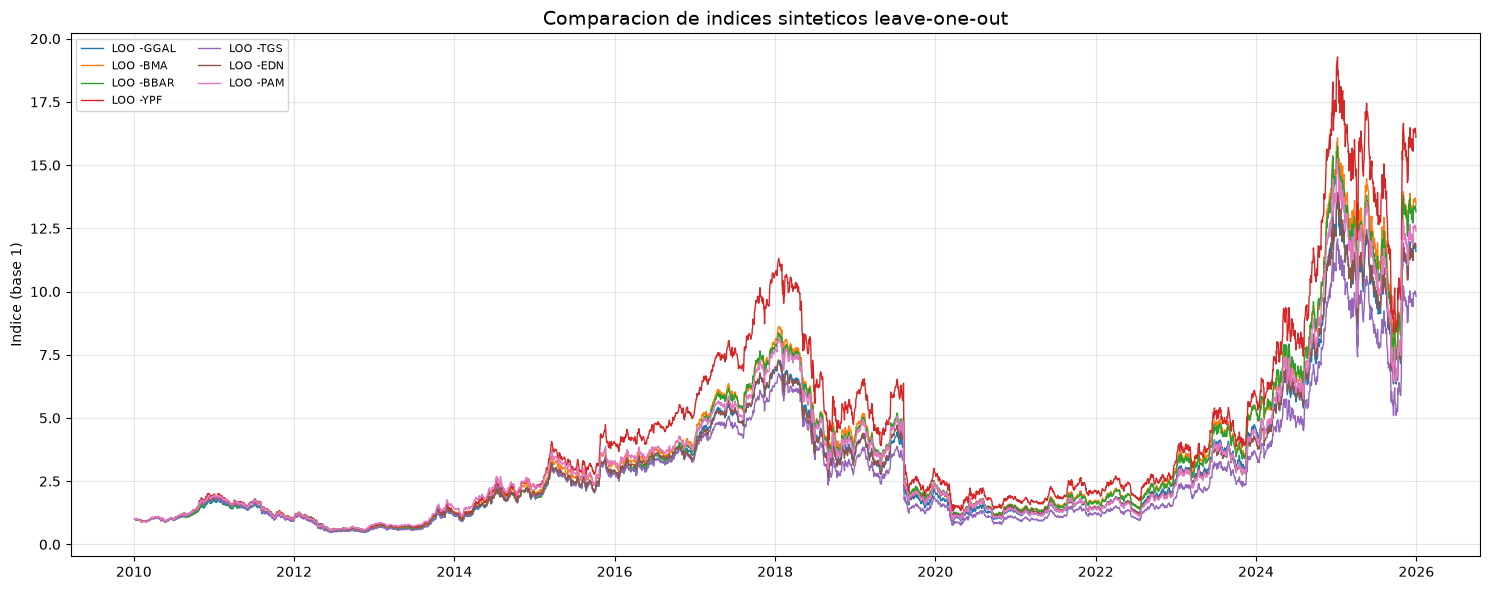

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

for ticker in tickers:
    ax.plot(indices_loo.index, indices_loo[ticker], label=f'LOO -{ticker}', linewidth=1)

ax.set_title('Comparacion de indices sinteticos leave-one-out', fontsize=14)
ax.set_ylabel('Indice (base 1)')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Estimacion de β rolling

Regresion OLS rodante de log(Precio) contra log(Indice LOO) con ventana de 252 ruedas.

$$\beta_t = \frac{\text{Cov}(\log P, \log I)}{\text{Var}(\log I)}$$

$$\alpha_t = \overline{\log P} - \beta_t \cdot \overline{\log I}$$

In [6]:
ventana = 252  # ~1 anio de ruedas

betas = {}
alphas = {}

for ticker in tickers:
    log_p = np.log(data[ticker])
    log_i = np.log(indices_loo[ticker])

    cov = log_p.rolling(ventana).cov(log_i)
    var = log_i.rolling(ventana).var()
    beta = cov / var
    alpha = log_p.rolling(ventana).mean() - beta * log_i.rolling(ventana).mean()

    betas[ticker] = beta
    alphas[ticker] = alpha

betas = pd.DataFrame(betas, index=returns.index)
alphas = pd.DataFrame(alphas, index=returns.index)

print(f"Betas rolling - Shape: {betas.shape}")
print(betas.head())

Betas rolling - Shape: (4022, 7)
            GGAL  BMA  BBAR  YPF  TGS  EDN  PAM
Date                                           
2010-01-05   NaN  NaN   NaN  NaN  NaN  NaN  NaN
2010-01-06   NaN  NaN   NaN  NaN  NaN  NaN  NaN
2010-01-07   NaN  NaN   NaN  NaN  NaN  NaN  NaN
2010-01-08   NaN  NaN   NaN  NaN  NaN  NaN  NaN
2010-01-11   NaN  NaN   NaN  NaN  NaN  NaN  NaN


### Evolucion de β en el tiempo

Graficamos como cambia la sensibilidad de cada accion al mercado.

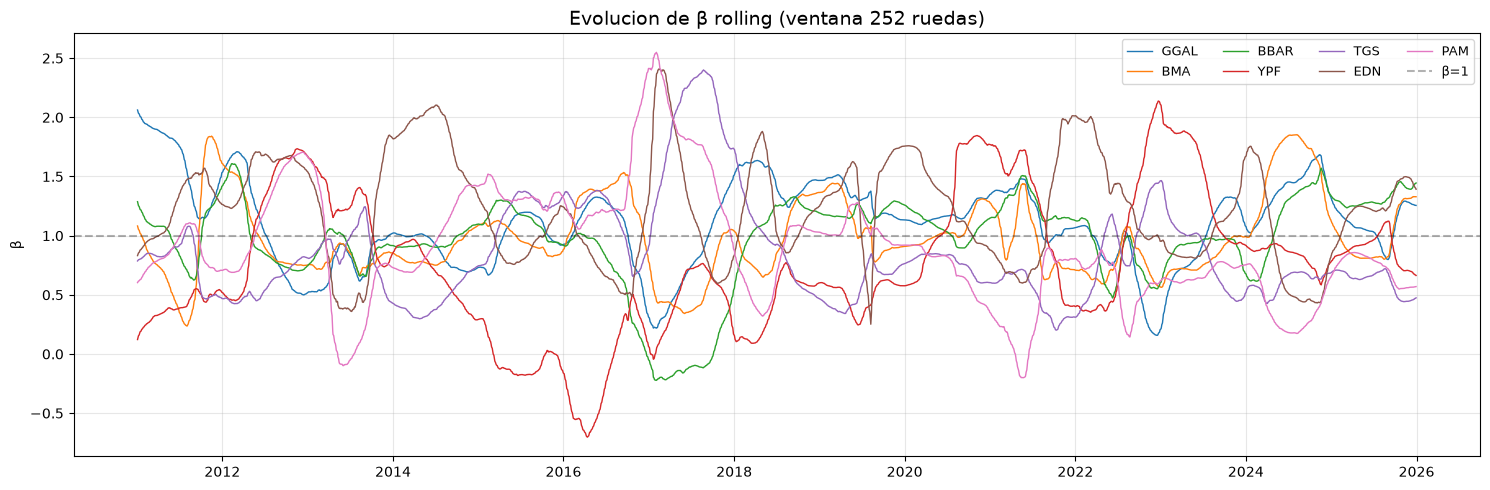

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))

for ticker in tickers:
    ax.plot(betas.index, betas[ticker], label=ticker, linewidth=1)

ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.3, label="β=1")
ax.set_title("Evolucion de β rolling (ventana 252 ruedas)", fontsize=14)
ax.set_ylabel("β")
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Spreads

Calculamos la divergencia relativa:

$$S_t = \log(P_t) - \alpha_t - \beta_t \cdot \log(I_{-ticker, t})$$

In [8]:
spreads = {}

for ticker in tickers:
    log_p = np.log(data[ticker])
    log_i = np.log(indices_loo[ticker])
    spread = log_p - alphas[ticker] - betas[ticker] * log_i
    spreads[ticker] = spread

spreads = pd.DataFrame(spreads, index=returns.index)

# descartamos las primeras filas donde no hay beta (ventana insuficiente)
spreads = spreads.dropna()

print(f"Spreads - Shape: {spreads.shape}")
spreads.head()

Spreads - Shape: (3771, 7)


,GGAL,BMA,BBAR,YPF,TGS,EDN,PAM
Date,,,,,,,
2011-01-03,-0.164600,-0.154763,-0.165260,0.192031,0.088933,0.129350,0.088465
2011-01-04,-0.161334,-0.149328,-0.170463,0.234255,0.088162,0.096200,0.067459
2011-01-05,-0.135254,-0.181598,-0.188460,0.251507,0.084436,0.080659,0.083541
2011-01-06,-0.123670,-0.167205,-0.182905,0.239580,0.075471,0.090496,0.062781
2011-01-07,-0.123577,-0.136912,-0.178291,0.205030,0.071685,0.089198,0.066419


### Visualizacion de spreads

Cada spread representa el movimiento particular de la accion no explicado por el panel.

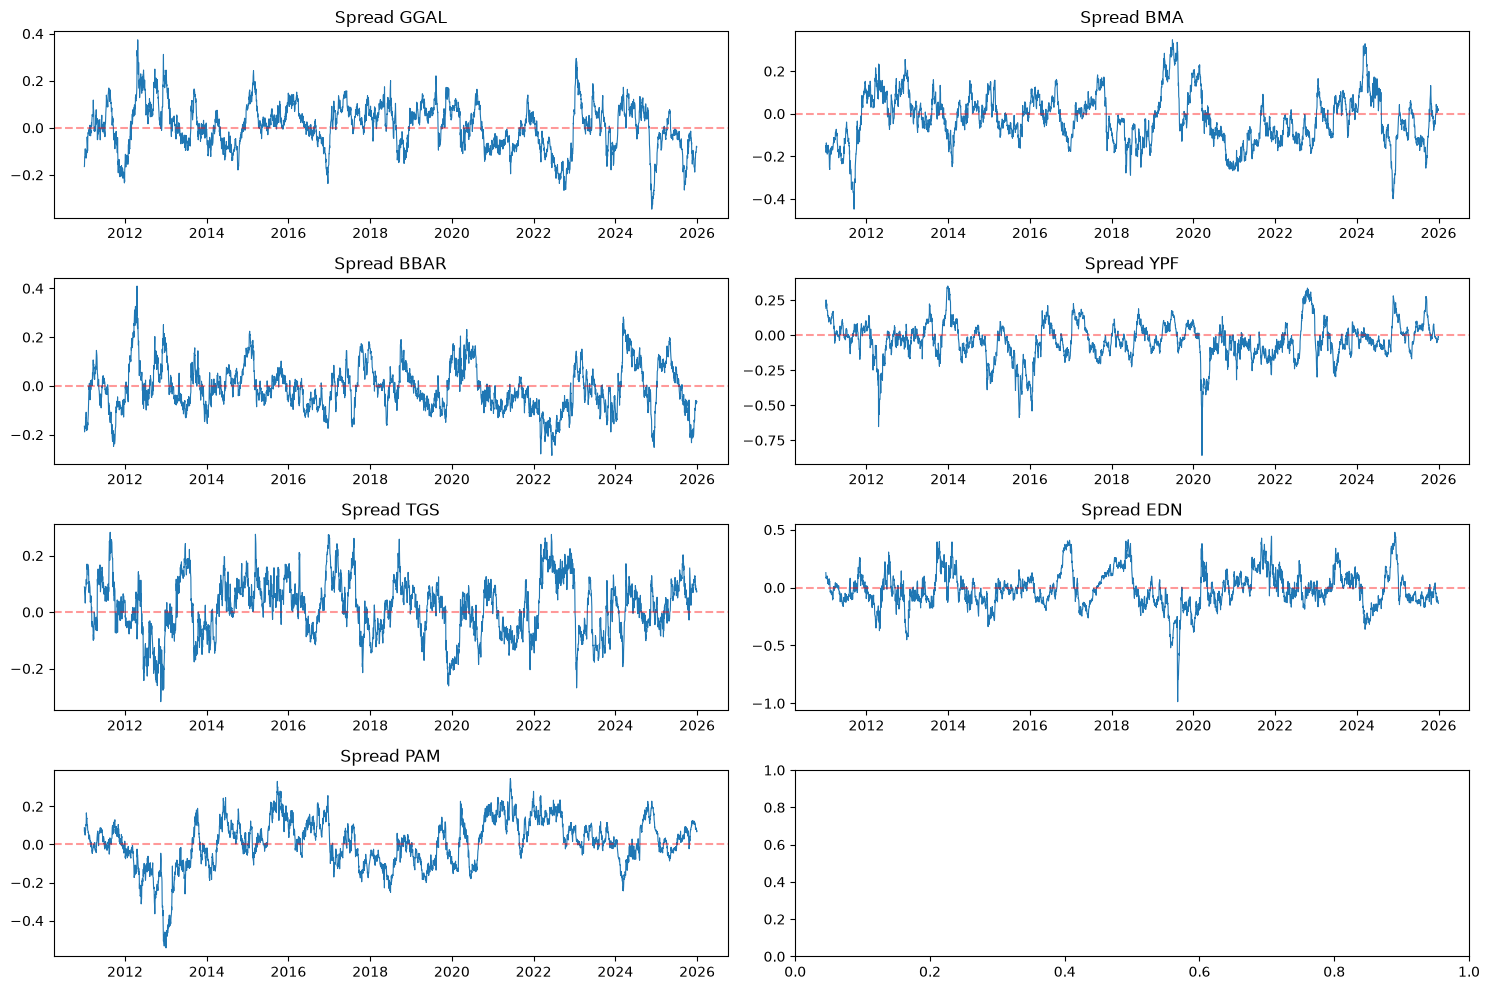

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    ax.plot(spreads.index, spreads[ticker], linewidth=0.8)
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.4)
    ax.set_title(f"Spread {ticker}")

plt.tight_layout()
plt.show()

## 6. Tests de estacionariedad

Aplicamos dos tests sobre cada spread:

- **ADF** (Augmented Dickey-Fuller): H0 = la serie tiene raiz unitaria (no estacionaria)
- **KPSS**: H0 = la serie es estacionaria

Combinando ambos podemos clasificar cada spread.

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

alpha = 0.05

resultados = []

for ticker in tickers:
    s = spreads[ticker].dropna()

    adf_stat, adf_pval, _, _, adf_cv, _ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")

    adf_rechaza = adf_pval < alpha
    kpss_no_rechaza = kpss_pval >= alpha

    if adf_rechaza and kpss_no_rechaza:
        conc = "Estacionario"
    elif not adf_rechaza and not kpss_no_rechaza:
        conc = "No estacionario"
    elif adf_rechaza and not kpss_no_rechaza:
        conc = "Ambos rechazan - dudoso"
    else:
        conc = "Ninguno rechaza - dudoso"

    resultados.append({
        "Ticker": ticker,
        "ADF stat": f"{adf_stat:.4f}",
        "ADF p-val": f"{adf_pval:.4f}",
        "KPSS stat": f"{kpss_stat:.4f}",
        "KPSS p-val": f"{kpss_pval:.4f}",
        "Conclusion": conc
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

/tmp/nix-shell-479194-2273238757/ipykernel_479896/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")


/tmp/nix-shell-479194-2273238757/ipykernel_479896/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")


/tmp/nix-shell-479194-2273238757/ipykernel_479896/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")


/tmp/nix-shell-479194-2273238757/ipykernel_479896/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")


/tmp/nix-shell-479194-2273238757/ipykernel_479896/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")


/tmp/nix-shell-479194-2273238757/ipykernel_479896/1884720380.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_cv = kpss(s, regression="c", nlags="auto")


,Ticker,ADF stat,ADF p-val,KPSS stat,KPSS p-val,Conclusion
0,GGAL,-5.9365,0.0000,0.6773,0.0156,Ambos rechazan - dudoso
1,BMA,-5.6648,0.0000,0.2434,0.1000,Estacionario
2,BBAR,-6.3925,0.0000,0.2294,0.1000,Estacionario
3,YPF,-6.5363,0.0000,0.1613,0.1000,Estacionario
4,TGS,-6.6073,0.0000,0.1250,0.1000,Estacionario
5,EDN,-6.3727,0.0000,0.1071,0.1000,Estacionario
6,PAM,-4.7023,0.0001,1.0699,0.0100,Ambos rechazan - dudoso


In [11]:
spreads.to_csv("data/spreads.csv")
print(f"Spreads exportados a data/spreads.csv - Shape: {spreads.shape}")

Spreads exportados a data/spreads.csv - Shape: (3771, 7)
